# Generative Model Comparison on MNIST

| Model | Description |
|-------|-------------|
| **VAE (Flow Prior)** | VAE with normalizing-flow prior (Gaussian decoder) |
| **VAE (Gaussian Prior)** | VAE with standard N(0,I) prior (Gaussian decoder) |
| **VAE (MoG Prior)** | VAE with mixture-of-Gaussians prior (Gaussian decoder) |
| **VAE (Flow + Bernoulli)** | VAE with flow prior and Bernoulli decoder (binarised MNIST) |
| **Beta-VAE (Gaussian)** | Standard beta-VAE with N(0,I) prior |
| **DDPM (U-Net)** | Pixel-space DDPM with U-Net backbone (ported from `DDPM/`) |
| **Latent DDPM** | DDPM in the latent space of a Gaussian-prior VAE |



In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

ROOT = Path.cwd().parent  # .../Advanced-Machine-learning
if str(ROOT) not in sys.path:
    
    sys.path.insert(0, str(ROOT))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Root:   {ROOT}')


Device: cuda
Root:   c:\Users\berko\Documents\Code\Advanced-Machine-learning


In [2]:

# --- Imports ---------------------------------------------------------
# Force-reload LatentDDPMwNB modules so code changes are picked up
# without restarting the kernel.
import importlib, sys

for mod_name in sorted(k for k in sys.modules if k.startswith('LatentDDPMwNB')):
    importlib.reload(sys.modules[mod_name])

from LatentDDPMwNB.data import get_standard_mnist, get_ddpm_mnist, get_real_images_for_fid
from LatentDDPMwNB.compare import (
    show_samples, measure_sampling_speed, evaluate_fid,
    compare_models, plot_latent_distributions, fid_vs_beta,
)

# Model wrappers (auto-registers them in ModelRegistry)
from LatentDDPMwNB.models.ddpm_unet import DDPMUNetModel
from LatentDDPMwNB.models.vae import VAEModel
from LatentDDPMwNB.models.latent_ddpm import LatentDDPMModel
from LatentDDPMwNB.models.registry import ModelRegistry

print('Registered models:', ModelRegistry.list())


Registered models: ['ddpm_unet', 'vae', 'latent_ddpm']


In [18]:

# --- Hyperparameters -------------------------------------------------
TEST_MODE = False   # Set to False for full training

BATCH_SIZE   = 64
LATENT_DIM   = 16
VAE_HIDDEN   = 2048
DDPM_T       = 1000

if TEST_MODE:
    # Flow VAE
    VAE_FLOW_EPOCHS = 2
    VAE_FLOW_LR     = 1e-3
    # Beta-VAE (Gaussian prior)
    BETA_VAE_EPOCHS = 2
    BETA_VAE_LR     = 1e-3
    # DDPM U-Net
    DDPM_UNET_EPOCHS = 2
    DDPM_UNET_LR     = 2e-4
    # Latent DDPM
    LDDPM_BETA              = 1e-2
    LDDPM_VAE_EPOCHS        = 2
    LDDPM_VAE_WARMUP_EPOCHS = 1
    LDDPM_DDPM_EPOCHS       = 2
    LDDPM_VAE_LR            = 1e-3
    LDDPM_DDPM_LR           = 2e-4
    # FID
    N_FID = 100
    print('** TEST MODE: using minimal epochs **')
else:
    # Flow VAE
    VAE_FLOW_EPOCHS = 50
    VAE_FLOW_LR     = 1e-3
    # Beta-VAE (Gaussian prior)
    BETA_VAE_EPOCHS = 50
    BETA_VAE_LR     = 1e-3
    # DDPM U-Net
    DDPM_UNET_EPOCHS = 50 if device == 'cuda' else 10
    DDPM_UNET_LR     = 2e-4
    # Latent DDPM
    LDDPM_BETA              = 1e-1
    LDDPM_VAE_EPOCHS        = 100 if device == 'cuda' else 60
    LDDPM_VAE_WARMUP_EPOCHS = LDDPM_VAE_EPOCHS // 2
    LDDPM_DDPM_EPOCHS       = 50 if device == 'cuda' else 20
    LDDPM_VAE_LR            = 1e-3
    LDDPM_DDPM_LR           = 2e-4
    # FID
    N_FID = 1000

# Output directory
OUTDIR = Path('project/outputs')
OUTDIR.mkdir(parents=True, exist_ok=True)


In [4]:
# --- Data ------------------------------------------------------------
# Standard MNIST [0,1] -- used by Latent DDPM and VAE
train_loader, test_loader = get_standard_mnist(BATCH_SIZE)

# DDPM MNIST [-1,1] -- used by the pixel-space DDPM U-Net
train_loader_ddpm, _ = get_ddpm_mnist(BATCH_SIZE)

print(f'Train batches (standard): {len(train_loader)}')
print(f'Train batches (DDPM):     {len(train_loader_ddpm)}')

Train batches (standard): 938
Train batches (DDPM):     938


---
# 2. Training

## 2.1 VAE (Flow Prior)

β-VAE training: 100%|██████████| 46900/46900 [31:08<00:00, 25.10it/s, beta=1.000000, epoch=50/50, loss=737.3015, lr=9.87e-07]


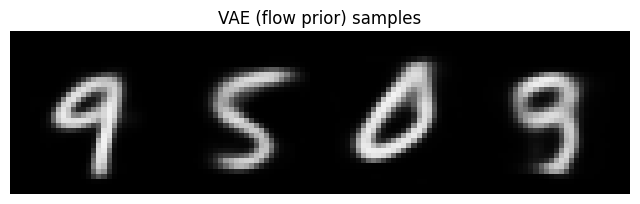

tensor([[[[0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          ...,
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015]]],


        [[[0.0019, 0.0019, 0.0019,  ..., 0.0019, 0.0019, 0.0019],
          [0.0019, 0.0019, 0.0019,  ..., 0.0019, 0.0019, 0.0019],
          [0.0019, 0.0019, 0.0019,  ..., 0.0019, 0.0019, 0.0019],
          ...,
          [0.0019, 0.0019, 0.0019,  ..., 0.0019, 0.0019, 0.0019],
          [0.0019, 0.0019, 0.0019,  ..., 0.0019, 0.0019, 0.0019],
          [0.0019, 0.0019, 0.0019,  ..., 0.0019, 0.0019, 0.0019]]],


        [[[0.0036, 0.0036, 0.0036,  ..., 0.0036, 0.0036, 0.0036],
          [0.0036, 0.0036, 0.0036,  ..., 0.0036, 0.0036, 0.0036],
          [0.0036, 0.0036, 0.0036,  ..

In [5]:
vae_flow = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='flow', model_name='vae_flow',
)
vae_flow.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_flow.save(OUTDIR / 'vae_flow.pt')
show_samples(vae_flow, n=4, title='VAE (flow prior) samples',
             save_path=OUTDIR / 'samples_vae_flow.png')

β-VAE training: 100%|██████████| 46900/46900 [18:30<00:00, 42.22it/s, beta=1.000000, epoch=50/50, loss=738.1367, lr=9.87e-07]


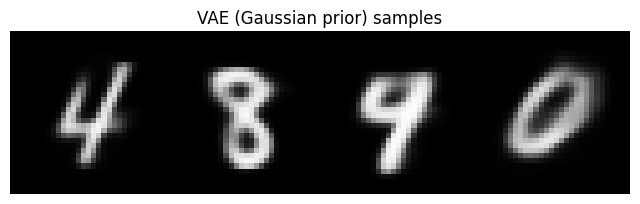

tensor([[[[0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0016, 0.0015, 0.0015],
          ...,
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015],
          [0.0015, 0.0015, 0.0015,  ..., 0.0015, 0.0015, 0.0015]]],


        [[[0.0016, 0.0016, 0.0016,  ..., 0.0016, 0.0016, 0.0016],
          [0.0016, 0.0016, 0.0016,  ..., 0.0016, 0.0016, 0.0016],
          [0.0016, 0.0016, 0.0016,  ..., 0.0016, 0.0016, 0.0016],
          ...,
          [0.0016, 0.0016, 0.0016,  ..., 0.0016, 0.0016, 0.0016],
          [0.0016, 0.0016, 0.0016,  ..., 0.0016, 0.0016, 0.0016],
          [0.0016, 0.0016, 0.0016,  ..., 0.0016, 0.0016, 0.0016]]],


        [[[0.0018, 0.0018, 0.0018,  ..., 0.0018, 0.0018, 0.0018],
          [0.0018, 0.0018, 0.0018,  ..., 0.0018, 0.0018, 0.0018],
          [0.0018, 0.0018, 0.0018,  ..

In [6]:
vae_gauss = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='gaussian', model_name='vae_gauss',
)
vae_gauss.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_gauss.save(OUTDIR / 'vae_gauss.pt')
show_samples(vae_gauss, n=4, title='VAE (Gaussian prior) samples',
             save_path=OUTDIR / 'samples_vae_gauss.png')

## 2.1b VAE (MoG Prior)

β-VAE training: 100%|██████████| 46900/46900 [20:52<00:00, 37.46it/s, beta=1.000000, epoch=50/50, loss=737.1566, lr=9.87e-07]


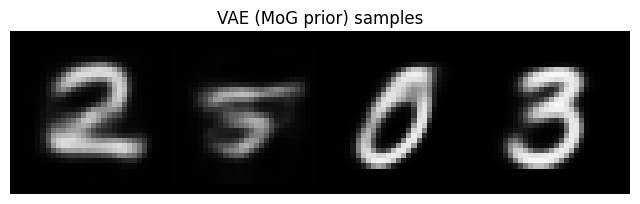

tensor([[[[0.0065, 0.0065, 0.0065,  ..., 0.0065, 0.0065, 0.0065],
          [0.0065, 0.0065, 0.0065,  ..., 0.0065, 0.0065, 0.0065],
          [0.0065, 0.0065, 0.0065,  ..., 0.0065, 0.0065, 0.0065],
          ...,
          [0.0065, 0.0065, 0.0065,  ..., 0.0065, 0.0065, 0.0065],
          [0.0065, 0.0065, 0.0065,  ..., 0.0065, 0.0065, 0.0065],
          [0.0065, 0.0065, 0.0065,  ..., 0.0065, 0.0065, 0.0065]]],


        [[[0.0056, 0.0056, 0.0056,  ..., 0.0056, 0.0056, 0.0056],
          [0.0056, 0.0056, 0.0056,  ..., 0.0056, 0.0056, 0.0056],
          [0.0056, 0.0056, 0.0056,  ..., 0.0056, 0.0056, 0.0056],
          ...,
          [0.0056, 0.0056, 0.0056,  ..., 0.0056, 0.0056, 0.0056],
          [0.0056, 0.0056, 0.0056,  ..., 0.0056, 0.0056, 0.0056],
          [0.0056, 0.0056, 0.0056,  ..., 0.0056, 0.0056, 0.0056]]],


        [[[0.0011, 0.0011, 0.0011,  ..., 0.0011, 0.0011, 0.0011],
          [0.0011, 0.0011, 0.0011,  ..., 0.0011, 0.0011, 0.0011],
          [0.0011, 0.0011, 0.0011,  ..

In [7]:
vae_mog = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='mog', mog_components=10, model_name='vae_mog',
)
vae_mog.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_mog.save(OUTDIR / 'vae_mog.pt')
show_samples(vae_mog, n=4, title='VAE (MoG prior) samples',
             save_path=OUTDIR / 'samples_vae_mog.png')

## 2.1c VAE (Flow Prior, Bernoulli Decoder)

Uses a **Bernoulli decoder** (for binarised MNIST) instead of the default Gaussian decoder.
This matches the original Part A implementation.

β-VAE training: 100%|██████████| 46900/46900 [29:28<00:00, 26.51it/s, beta=1.000000, epoch=50/50, loss=92.4876, lr=9.87e-07] 


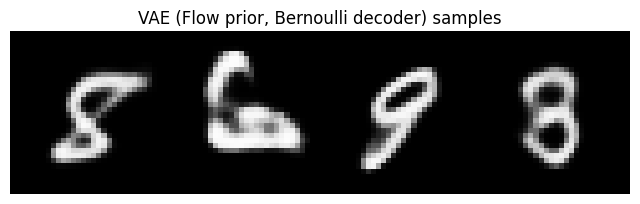

tensor([[[[1.3865e-04, 1.3865e-04, 1.3865e-04,  ..., 1.3865e-04,
           1.3865e-04, 1.3865e-04],
          [1.3865e-04, 1.3865e-04, 1.3865e-04,  ..., 1.3865e-04,
           1.3865e-04, 1.3865e-04],
          [1.3865e-04, 1.3865e-04, 1.3602e-04,  ..., 2.1858e-04,
           1.3865e-04, 1.3865e-04],
          ...,
          [1.3865e-04, 1.3865e-04, 1.8329e-04,  ..., 1.9057e-04,
           2.1238e-04, 1.3865e-04],
          [1.3865e-04, 1.3865e-04, 1.3865e-04,  ..., 1.6735e-04,
           1.3865e-04, 1.3865e-04],
          [1.3865e-04, 1.3865e-04, 1.3865e-04,  ..., 1.3865e-04,
           1.3865e-04, 1.3865e-04]]],


        [[[3.1238e-05, 3.1238e-05, 3.1238e-05,  ..., 3.1238e-05,
           3.1238e-05, 3.1238e-05],
          [3.1238e-05, 3.1238e-05, 3.1238e-05,  ..., 3.1238e-05,
           3.1238e-05, 3.1238e-05],
          [3.1238e-05, 3.1238e-05, 7.0146e-05,  ..., 1.2562e-04,
           3.1238e-05, 3.1238e-05],
          ...,
          [3.1238e-05, 3.1238e-05, 2.3396e-05,  ..., 7.44

In [8]:
vae_bernoulli = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='flow', decoder_type='bernoulli', model_name='vae_bernoulli',
)
vae_bernoulli.train_model(train_loader, epochs=VAE_FLOW_EPOCHS, lr=VAE_FLOW_LR)
vae_bernoulli.save(OUTDIR / 'vae_bernoulli.pt')
show_samples(vae_bernoulli, n=4, title='VAE (Flow prior, Bernoulli decoder) samples',
             save_path=OUTDIR / 'samples_vae_bernoulli.png')

## 2.2 Beta-VAE (Gaussian Prior)

β-VAE training: 100%|██████████| 46900/46900 [18:41<00:00, 41.82it/s, beta=1.000000, epoch=50/50, loss=738.0773, lr=9.87e-07]


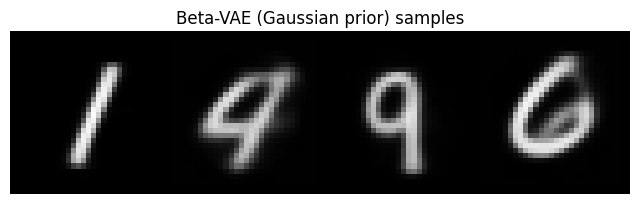

tensor([[[[0.0006, 0.0006, 0.0006,  ..., 0.0006, 0.0006, 0.0006],
          [0.0006, 0.0006, 0.0006,  ..., 0.0006, 0.0006, 0.0006],
          [0.0006, 0.0006, 0.0006,  ..., 0.0006, 0.0006, 0.0006],
          ...,
          [0.0006, 0.0006, 0.0006,  ..., 0.0006, 0.0006, 0.0006],
          [0.0006, 0.0006, 0.0006,  ..., 0.0006, 0.0006, 0.0006],
          [0.0006, 0.0006, 0.0006,  ..., 0.0006, 0.0006, 0.0006]]],


        [[[0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
          [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
          [0.0050, 0.0050, 0.0050,  ..., 0.0051, 0.0050, 0.0050],
          ...,
          [0.0050, 0.0050, 0.0051,  ..., 0.0051, 0.0051, 0.0050],
          [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050],
          [0.0050, 0.0050, 0.0050,  ..., 0.0050, 0.0050, 0.0050]]],


        [[[0.0027, 0.0027, 0.0027,  ..., 0.0027, 0.0027, 0.0027],
          [0.0027, 0.0027, 0.0027,  ..., 0.0027, 0.0027, 0.0027],
          [0.0027, 0.0027, 0.0027,  ..

In [9]:
beta_vae = VAEModel(
    device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN,
    prior_type='gaussian', model_name='beta_vae',
)
beta_vae.train_model(train_loader, epochs=BETA_VAE_EPOCHS, lr=BETA_VAE_LR)
beta_vae.save(OUTDIR / 'beta_vae.pt')
show_samples(beta_vae, n=4, title='Beta-VAE (Gaussian prior) samples',
             save_path=OUTDIR / 'samples_beta_vae.png')

## 2.3 DDPM U-Net (Pixel-space DDPM)

Training: 100%|██████████| 46900/46900 [31:47<00:00, 24.59it/s, epoch=50/50, loss=⠀     17.3441]


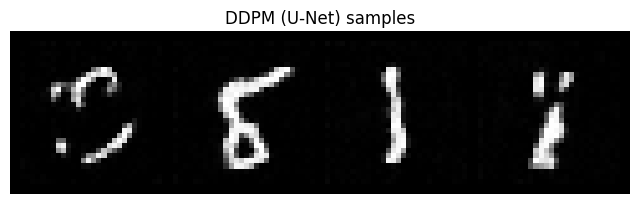

tensor([[[[0.0000, 0.0024, 0.0118,  ..., 0.0077, 0.0109, 0.0076],
          [0.0000, 0.0033, 0.0013,  ..., 0.0000, 0.0000, 0.0168],
          [0.0092, 0.0000, 0.0000,  ..., 0.0000, 0.0001, 0.0132],
          ...,
          [0.0055, 0.0000, 0.0054,  ..., 0.0000, 0.0010, 0.0036],
          [0.0114, 0.0111, 0.0116,  ..., 0.0000, 0.0012, 0.0147],
          [0.0000, 0.0000, 0.0134,  ..., 0.0000, 0.0196, 0.0246]]],


        [[[0.0154, 0.0148, 0.0045,  ..., 0.0000, 0.0000, 0.0175],
          [0.0000, 0.0008, 0.0113,  ..., 0.0018, 0.0000, 0.0067],
          [0.0059, 0.0016, 0.0000,  ..., 0.0092, 0.0125, 0.0000],
          ...,
          [0.0000, 0.0055, 0.0000,  ..., 0.0075, 0.0044, 0.0064],
          [0.0270, 0.0000, 0.0021,  ..., 0.0000, 0.0060, 0.0000],
          [0.0215, 0.0060, 0.0022,  ..., 0.0000, 0.0027, 0.0081]]],


        [[[0.0323, 0.0057, 0.0206,  ..., 0.0091, 0.0106, 0.0121],
          [0.0024, 0.0000, 0.0041,  ..., 0.0106, 0.0142, 0.0016],
          [0.0004, 0.0000, 0.0013,  ..

In [10]:
ddpm = DDPMUNetModel(device=device, T=DDPM_T)
ddpm.train_model(train_loader_ddpm, epochs=DDPM_UNET_EPOCHS, lr=DDPM_UNET_LR)
ddpm.save(OUTDIR / 'ddpm_unet.pt')
show_samples(ddpm, n=4, title='DDPM (U-Net) samples',
             save_path=OUTDIR / 'samples_ddpm_unet.png')

## 2.4 Latent DDPM (Gaussian-prior VAE + DDPM in z-space)

The VAE inside the Latent DDPM uses a **standard Gaussian prior N(0, I)**.
The DDPM itself serves as the learned prior over latent codes.


In [11]:
latent_ddpm = LatentDDPMModel(
    device=device,
    beta=LDDPM_BETA,
    latent_dim=LATENT_DIM,
    vae_hidden=VAE_HIDDEN,
    T=DDPM_T,
)

# Stage 1: Train the Gaussian-prior VAE inside Latent DDPM

In [12]:
print('Stage 1: Training Gaussian-prior VAE (Gaussian likelihood)...')
latent_ddpm.train_vae(
    train_loader,
    epochs=LDDPM_VAE_EPOCHS,
    lr=LDDPM_VAE_LR,
    beta_warmup_epochs=int(LDDPM_VAE_WARMUP_EPOCHS),
)

Stage 1: Training Gaussian-prior VAE (Gaussian likelihood)...


β-VAE training: 100%|██████████| 93800/93800 [37:08<00:00, 42.09it/s, beta=0.100000, epoch=100/100, loss=726.0012, lr=2.47e-07]



--- Gaussian-Prior VAE Quality Check ---


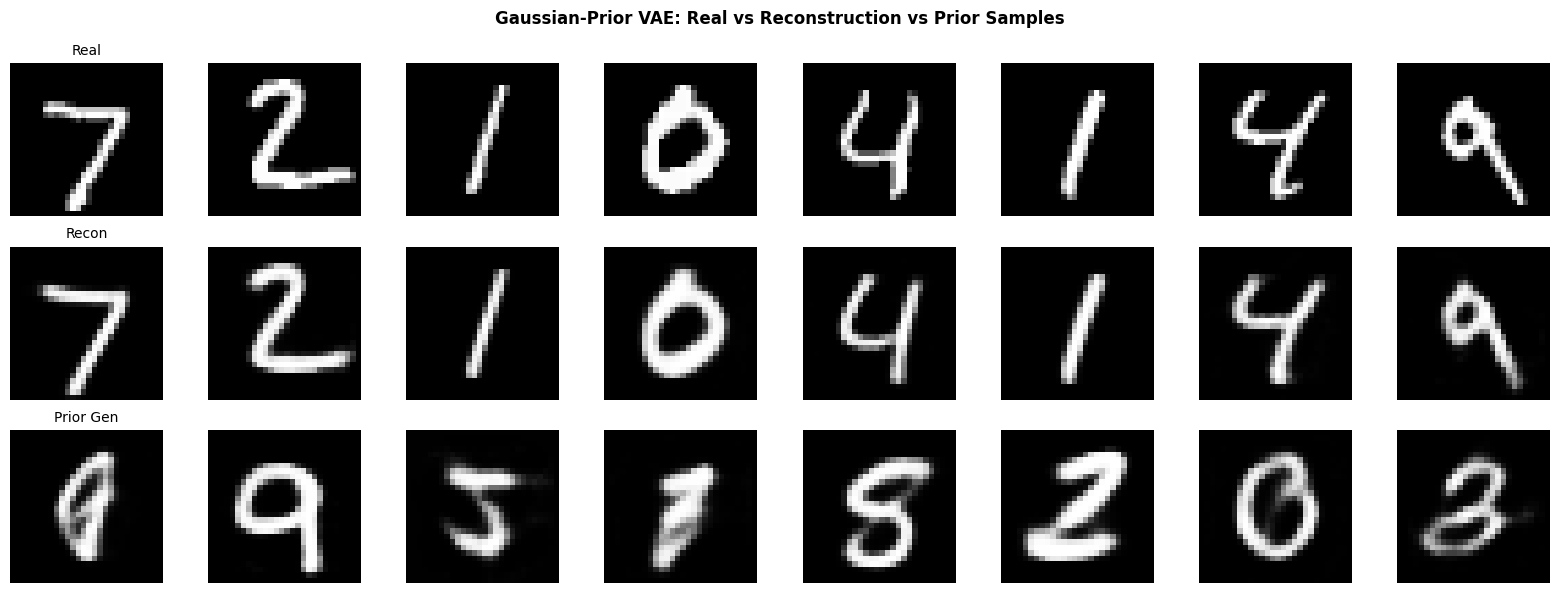

Quality check saved to beta_vae_quality_check.png


In [13]:
# Show comparison: Real vs reconstruction vs Gaussian-prior sample
print('\n--- Gaussian-Prior VAE Quality Check ---')

real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    q = latent_ddpm.vae.encode(real_flat)
    recon = latent_ddpm.vae.decode_mean(q.mean)
    prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)

real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
gen_imgs = prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')
    axes[2, i].imshow(gen_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('Prior Gen' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')

fig.suptitle('Gaussian-Prior VAE: Real vs Reconstruction vs Prior Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'beta_vae_quality_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Quality check saved to beta_vae_quality_check.png')


In [14]:
# Stage 2: Train the latent DDPM
print('\nStage 2: Training DDPM in latent space...')
latent_ddpm.train_ddpm(train_loader, epochs=LDDPM_DDPM_EPOCHS, lr=LDDPM_DDPM_LR)

latent_ddpm.save(OUTDIR / 'latent_ddpm.pt')
print('Saved latent DDPM model.')


Stage 2: Training DDPM in latent space...


Training: 100%|██████████| 46900/46900 [05:07<00:00, 152.55it/s, epoch=50/50, loss=⠀      4.3499]


Saved latent DDPM model.



--- Latent DDPM Diagnostic ---
Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space



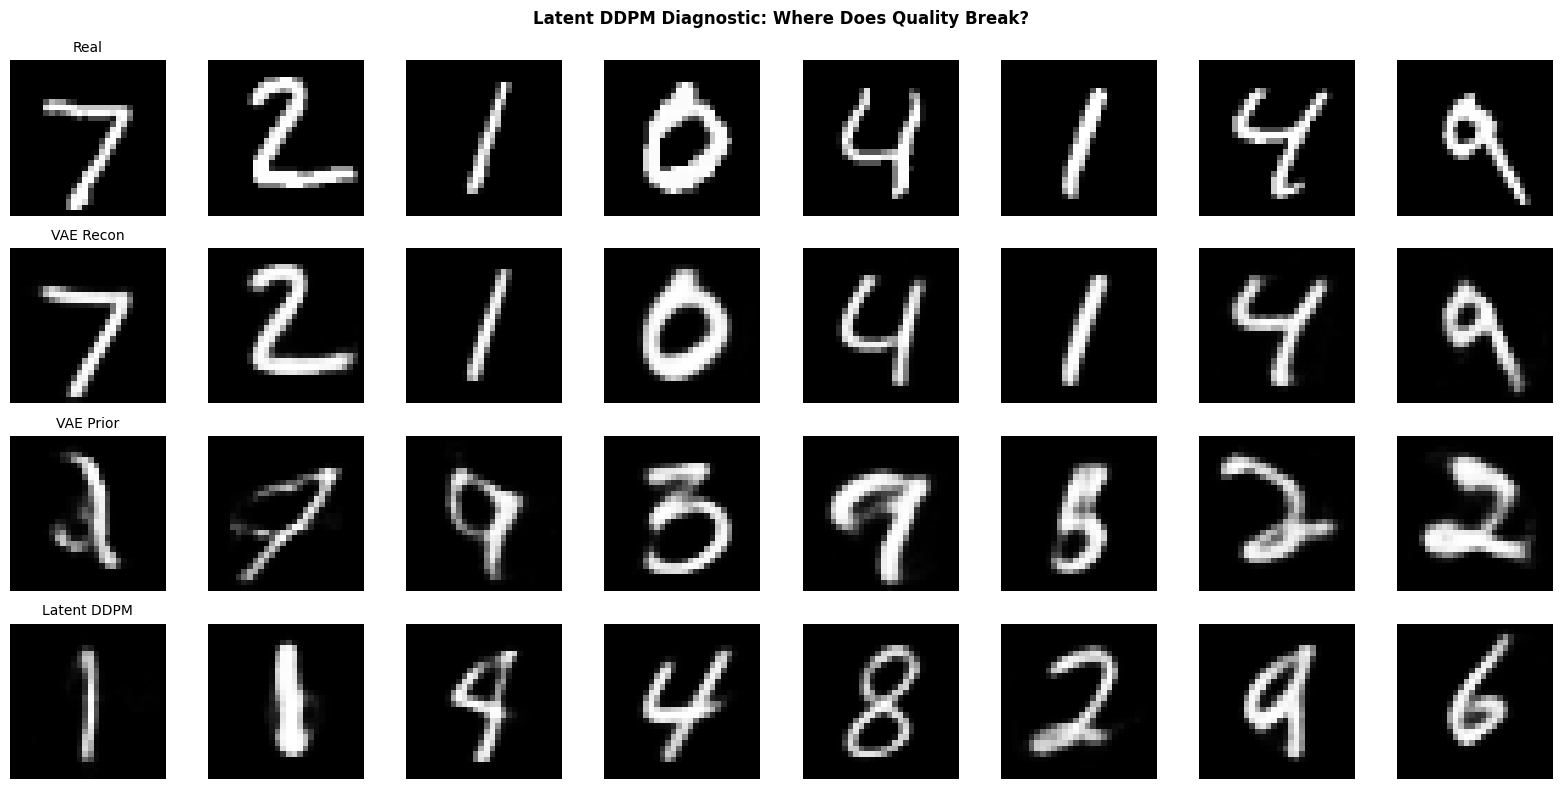

DIAGNOSIS:
  Row 1 (Real): Ground truth
  Row 2 (VAE Recon): Should be sharp -- checks if VAE encoder works
  Row 3 (VAE Prior): z ~ N(0,I) Gaussian prior -- checks if VAE prior is aligned
  Row 4 (Latent DDPM): z ~ DDPM -- checks if DDPM improved the prior

If Row 3 is blurry: beta is too low -- increase beta
If Row 3 is OK but Row 4 is worse: DDPM training failed -- more epochs needed
Diagnostic saved to latent_ddpm_diagnostic.png


In [15]:
# DIAGNOSTIC: Compare VAE Prior vs Latent DDPM
print('\n--- Latent DDPM Diagnostic ---')
print('Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space\n')

real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    q = latent_ddpm.vae.encode(real_flat)
    vae_recon = latent_ddpm.vae.decode_mean(q.mean)
    vae_prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)
    ddpm_samples = latent_ddpm.sample(n_samples=8).to(device)
    if ddpm_samples.dim() == 4:
        ddpm_samples = ddpm_samples.view(ddpm_samples.size(0), -1)

real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = vae_recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
vae_prior_imgs = vae_prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
ddpm_imgs = ddpm_samples.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('VAE Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')
    axes[2, i].imshow(vae_prior_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('VAE Prior' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')
    axes[3, i].imshow(ddpm_imgs[i, 0].numpy(), cmap='gray')
    axes[3, i].set_title('Latent DDPM' if i == 0 else '', fontsize=10)
    axes[3, i].axis('off')

fig.suptitle('Latent DDPM Diagnostic: Where Does Quality Break?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'latent_ddpm_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

print('DIAGNOSIS:')
print('  Row 1 (Real): Ground truth')
print('  Row 2 (VAE Recon): Should be sharp -- checks if VAE encoder works')
print('  Row 3 (VAE Prior): z ~ N(0,I) Gaussian prior -- checks if VAE prior is aligned')
print('  Row 4 (Latent DDPM): z ~ DDPM -- checks if DDPM improved the prior')
print()
print('If Row 3 is blurry: beta is too low -- increase beta')
print('If Row 3 is OK but Row 4 is worse: DDPM training failed -- more epochs needed')
print('Diagnostic saved to latent_ddpm_diagnostic.png')


---
# 3. Evaluation

## 3.1 Visual Reality Comparison: Real MNIST vs Generated Samples

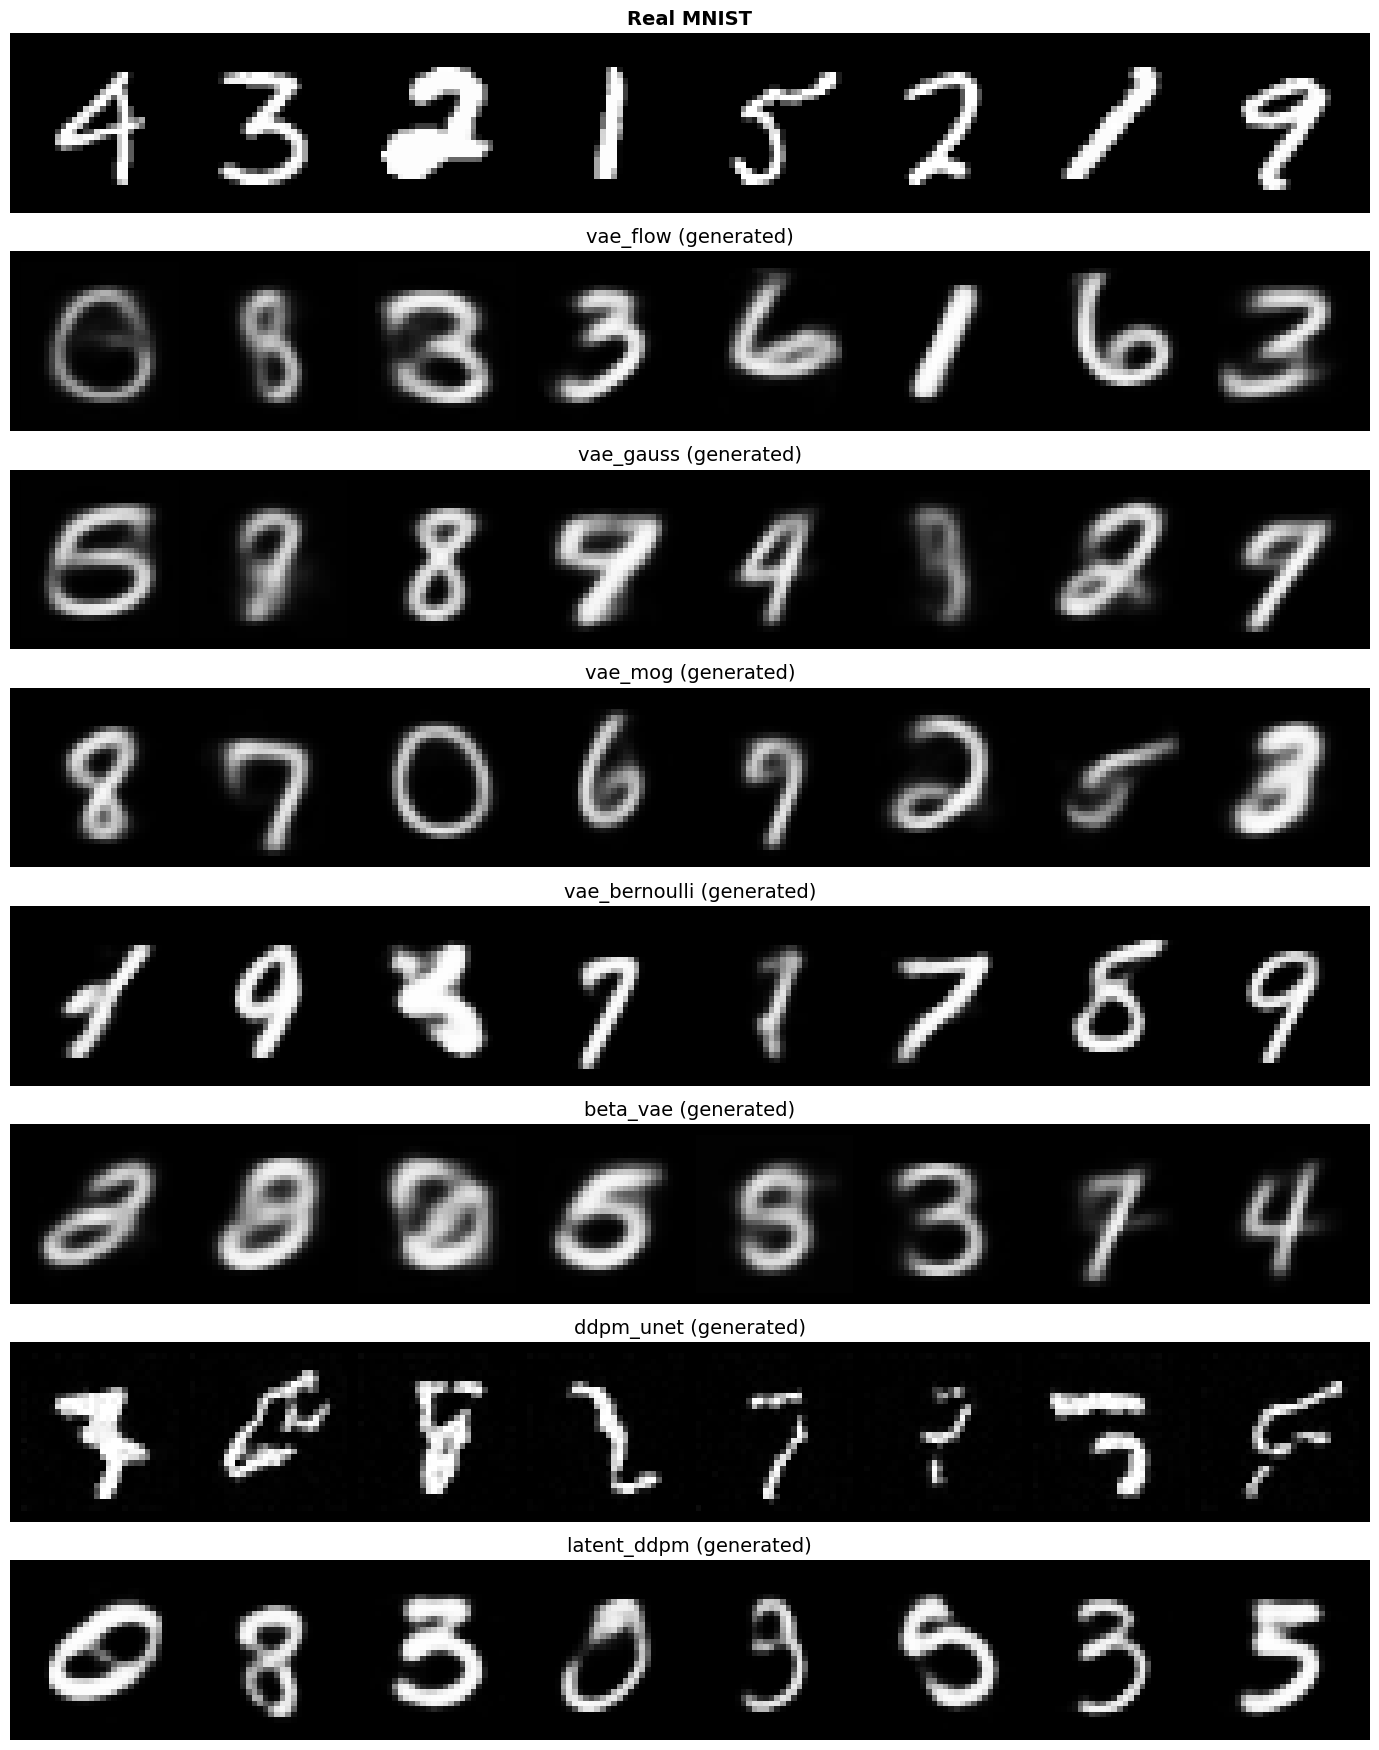

In [16]:
def show_comparison(real_loader, models, n_samples=8, save_path=None):
    """Top row = real MNIST, then one row per model with generated samples."""
    real_batch = next(iter(real_loader))
    if isinstance(real_batch, (list, tuple)):
        real_batch = real_batch[0]
    real_imgs = real_batch[:n_samples].cpu()
    if real_imgs.dim() == 2:
        real_imgs = real_imgs.view(-1, 1, 28, 28)
    real_imgs = real_imgs.clamp(0.0, 1.0)

    n_rows = 1 + len(models)
    fig, axes = plt.subplots(n_rows, 1, figsize=(n_samples * 2, 2.2 * n_rows))
    if n_rows == 1:
        axes = [axes]

    grid_real = make_grid(real_imgs, nrow=n_samples, padding=2, normalize=False)
    axes[0].imshow(grid_real.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
    axes[0].set_title('Real MNIST', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    for i, m in enumerate(models):
        with torch.no_grad():
            gen = m.sample(n_samples).cpu().clamp(0.0, 1.0)
        if gen.dim() == 2:
            gen = gen.view(-1, 1, 28, 28)
        grid_gen = make_grid(gen, nrow=n_samples, padding=2, normalize=False)
        axes[i + 1].imshow(grid_gen.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
        axes[i + 1].set_title(f'{m.name} (generated)', fontsize=14)
        axes[i + 1].axis('off')

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

# All models (including new VAE variants)
models_to_eval = [vae_flow, vae_gauss, vae_mog, vae_bernoulli, beta_vae, ddpm, latent_ddpm]

show_comparison(
    train_loader, models_to_eval, n_samples=8,
    save_path=OUTDIR / 'comparison_real_vs_generated.png',
)

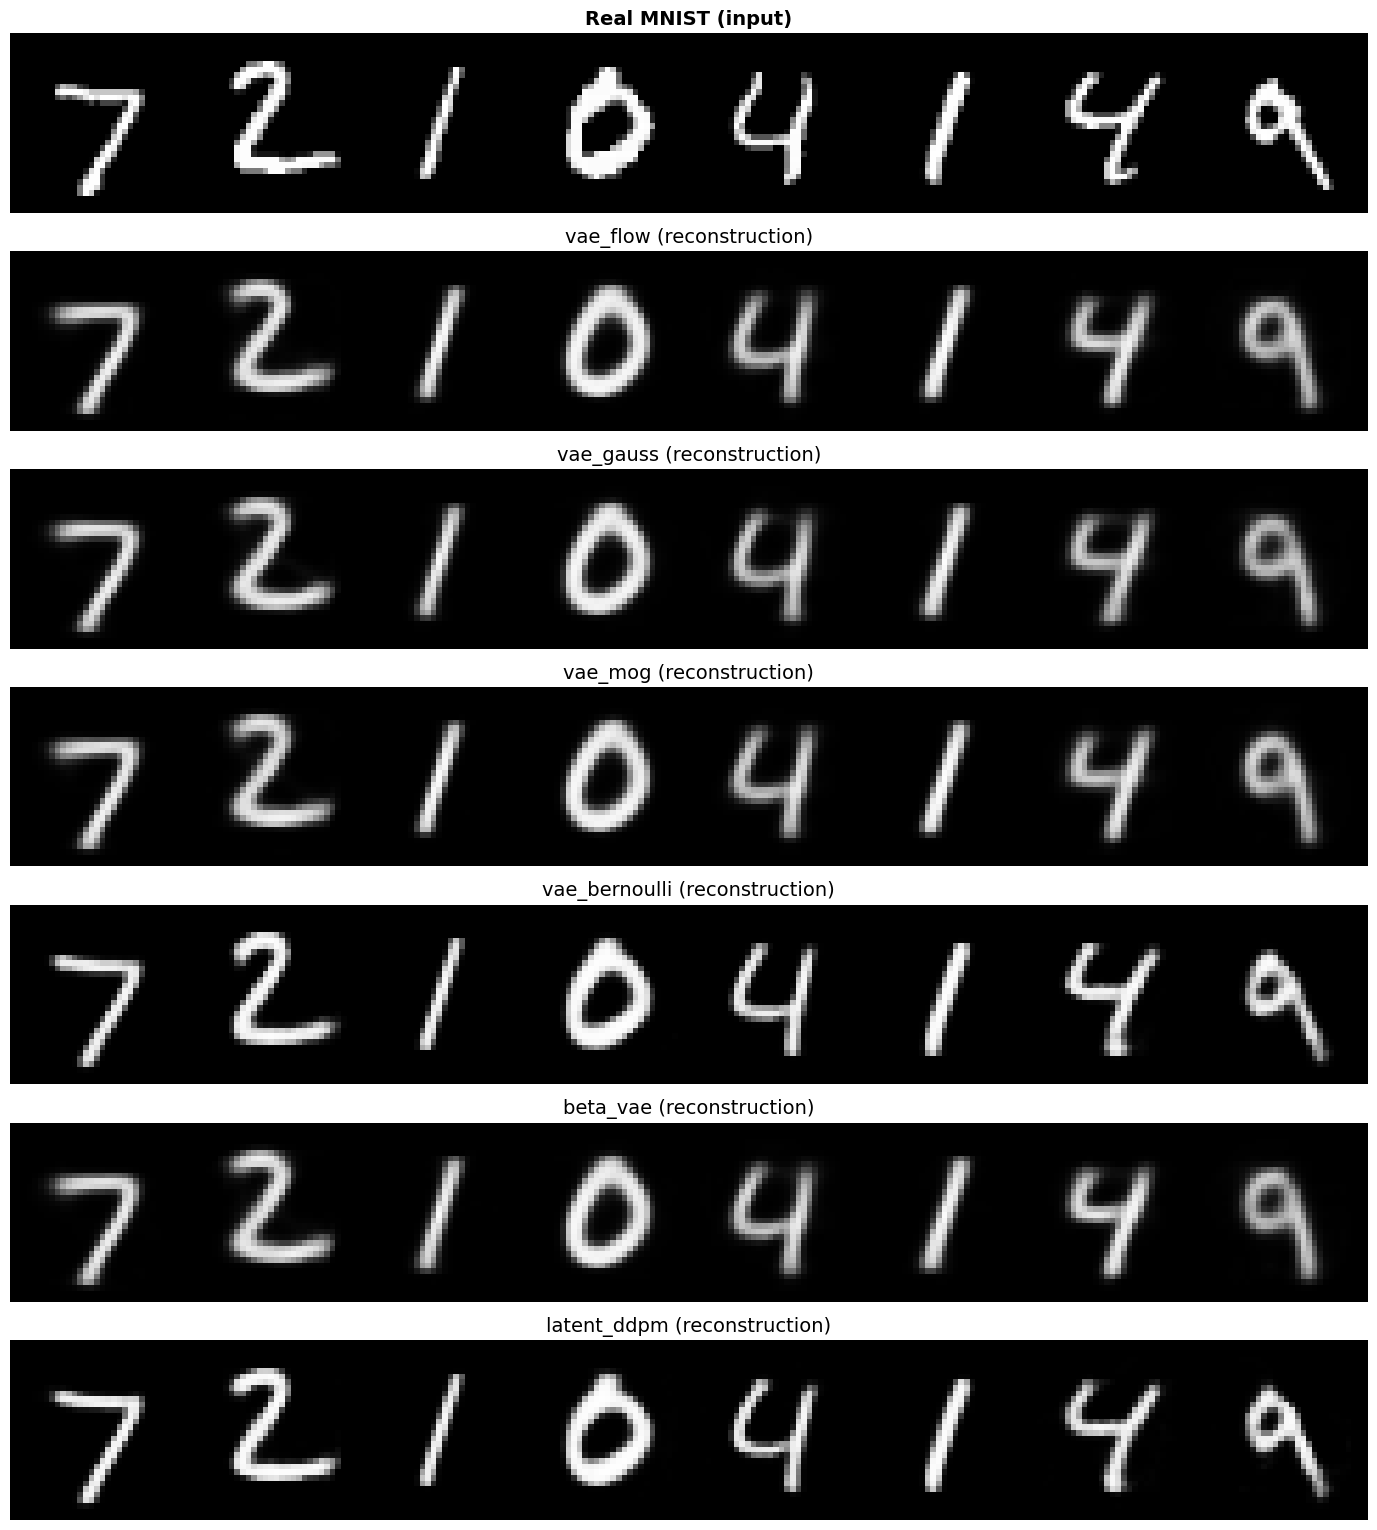

In [23]:

def show_reconstructions(real_loader, models, n_samples=8, save_path=None):
    """For each model that has an encoder, show real vs reconstruction side-by-side."""
    real_batch = next(iter(real_loader))
    if isinstance(real_batch, (list, tuple)):
        real_batch = real_batch[0]
    real_imgs = real_batch[:n_samples].to(device)
    real_flat = real_imgs.view(n_samples, -1) if real_imgs.dim() > 2 else real_imgs

    vae_models = [m for m in models if hasattr(m, 'vae') or hasattr(m, 'encode')]
    # Also include LatentDDPMModel which has an inner vae
    encodable = []
    for m in models:
        if hasattr(m, 'encode'):
            encodable.append((m.name, lambda x, m=m: m.encode_decode(x)))
        elif hasattr(m, 'vae') and hasattr(m.vae, 'encode'):
            encodable.append((m.name, lambda x, m=m: m.vae.decode_mean(m.vae.encode(x).mean)))
        elif hasattr(m, 'model') and hasattr(m.model, 'encode'):
            encodable.append((m.name, lambda x, m=m: m.model.decode_mean(m.model.encode(x).mean)))

    if not encodable:
        print("No models with an encoder found.")
        return

    n_rows = 1 + len(encodable)
    fig, axes = plt.subplots(n_rows, 1, figsize=(n_samples * 2, 2.2 * n_rows))
    if n_rows == 1:
        axes = [axes]

    real_show = real_imgs.cpu().clamp(0.0, 1.0)
    if real_show.dim() == 2:
        real_show = real_show.view(-1, 1, 28, 28)
    grid_real = make_grid(real_show, nrow=n_samples, padding=2, normalize=False)
    axes[0].imshow(grid_real.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
    axes[0].set_title('Real MNIST (input)', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    for i, (name, recon_fn) in enumerate(encodable):
        with torch.no_grad():
            recon = recon_fn(real_flat).cpu().clamp(0.0, 1.0)
        if recon.dim() == 2:
            recon = recon.view(-1, 1, 28, 28)
        grid = make_grid(recon, nrow=n_samples, padding=2, normalize=False)
        axes[i + 1].imshow(grid.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
        axes[i + 1].set_title(f'{name} (reconstruction)', fontsize=14)
        axes[i + 1].axis('off')

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

show_reconstructions(
    test_loader, models_to_eval, n_samples=8,
    save_path=OUTDIR / 'comparison_reconstructions.png',
)


## 3.2 FID Scores

In [19]:
fid_results = {}
for m in models_to_eval:
    fid = evaluate_fid(m, n_gen=N_FID, device=device)
    fid_results[m.name] = fid
    print(f'{m.name:20s}  FID = {fid:.2f}')

vae_flow              FID = 64.83
vae_gauss             FID = 76.97
vae_mog               FID = 54.57
vae_bernoulli         FID = 26.85
beta_vae              FID = 75.98
ddpm_unet             FID = 42.81
latent_ddpm           FID = 21.58


## 3.3 FID vs β (Latent DDPM)

Sweep over different β values for the β-VAE inside the Latent DDPM.


--- β = 1e-06 ---


Training: 100%|██████████| 46900/46900 [05:52<00:00, 132.93it/s, epoch=50/50, loss=⠀      6.8528]


  β=1.0e-06  →  FID=7.25

--- β = 0.0001 ---


Training: 100%|██████████| 46900/46900 [05:35<00:00, 139.96it/s, epoch=50/50, loss=⠀      5.4425]


  β=1.0e-04  →  FID=8.11

--- β = 0.01 ---


...

  β=1.0e-02  →  FID=10.63

--- β = 0.1 ---


Training: 100%|██████████| 46900/46900 [05:52<00:00, 132.97it/s, epoch=50/50, loss=⠀      4.5587]


  β=1.0e-01  →  FID=16.59

--- β = 1.0 ---


Training: 100%|██████████| 46900/46900 [05:38<00:00, 138.75it/s, epoch=50/50, loss=⠀      1.6470]


  β=1.0e+00  →  FID=73.92


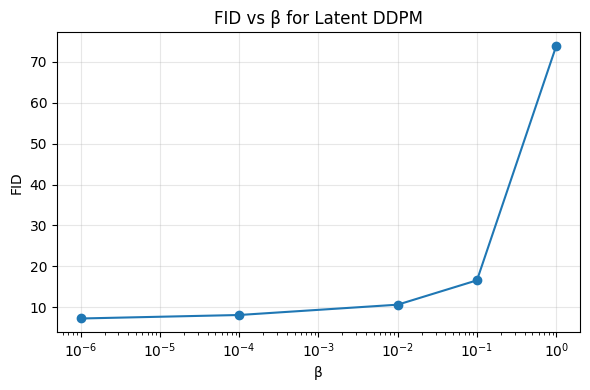

  β = 1.0e-06  →  FID = 7.25
  β = 1.0e-04  →  FID = 8.11
  β = 1.0e-02  →  FID = 10.63
  β = 1.0e-01  →  FID = 16.59
  β = 1.0e+00  →  FID = 73.92


In [20]:
# β values to sweep (adjust as needed)
betas_to_test = [1e-6, 1e-4, 1e-2, 1e-1, 1.0]

beta_fid_results = fid_vs_beta(
    betas=betas_to_test,
    train_loader=train_loader,
    device=device,
    latent_dim=LATENT_DIM,
    vae_epochs=LDDPM_VAE_EPOCHS,
    ddpm_epochs=LDDPM_DDPM_EPOCHS,
    n_fid=N_FID,
    save_path=OUTDIR / 'fid_vs_beta.png',
)

for b, f in beta_fid_results.items():
    print(f'  β = {b:.1e}  →  FID = {f:.2f}')

## 3.4 Sampling Speed

In [21]:
speed_results = {}
for m in models_to_eval:
    sr = measure_sampling_speed(m, n_samples=100)
    speed_results[m.name] = sr
    print(f"{m.name:20s}  {sr['samples_per_sec']:.1f} samples/s  "
          f"({sr['total_time_s']:.2f}s for {sr['n_samples']} samples)")

vae_flow              10937.1 samples/s  (0.01s for 100 samples)
vae_gauss             31149.7 samples/s  (0.00s for 100 samples)
vae_mog               16656.4 samples/s  (0.01s for 100 samples)
vae_bernoulli         13457.3 samples/s  (0.01s for 100 samples)
beta_vae              38412.8 samples/s  (0.00s for 100 samples)
ddpm_unet             5.4 samples/s  (18.46s for 100 samples)
latent_ddpm           104.7 samples/s  (0.95s for 100 samples)


## 3.5 Latent Space Analysis

Compare three distributions in the first two latent dimensions:
- **VAE prior** — $\mathcal{N}(0, I)$
- **Aggregate posterior** — $\frac{1}{N} \sum q(z \mid x_i)$
- **Learned DDPM prior** — samples from the latent-space DDPM

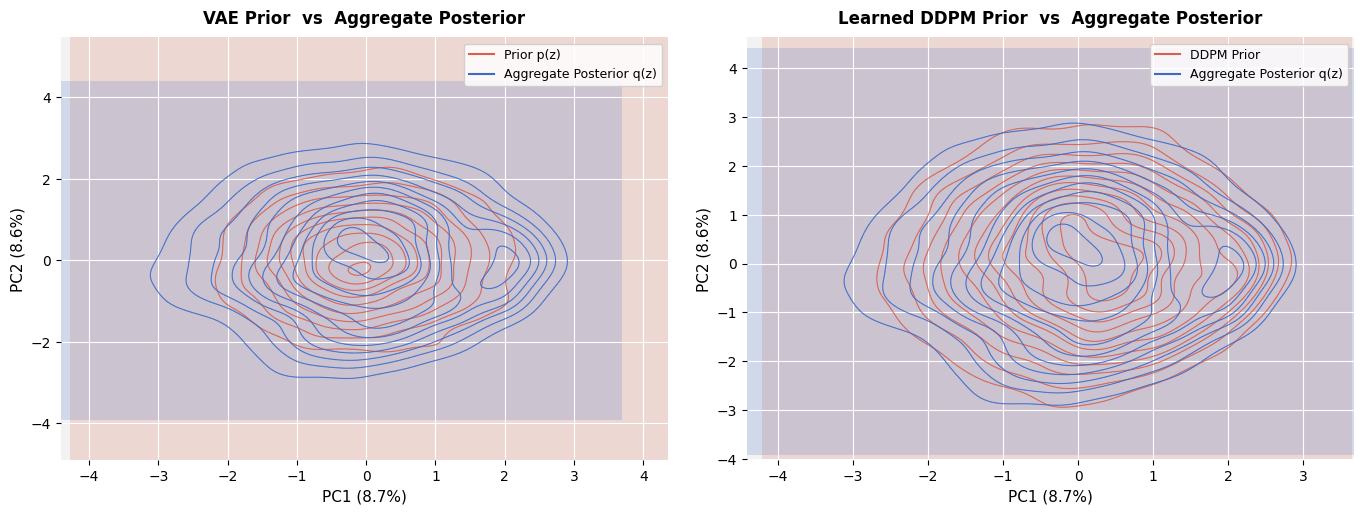

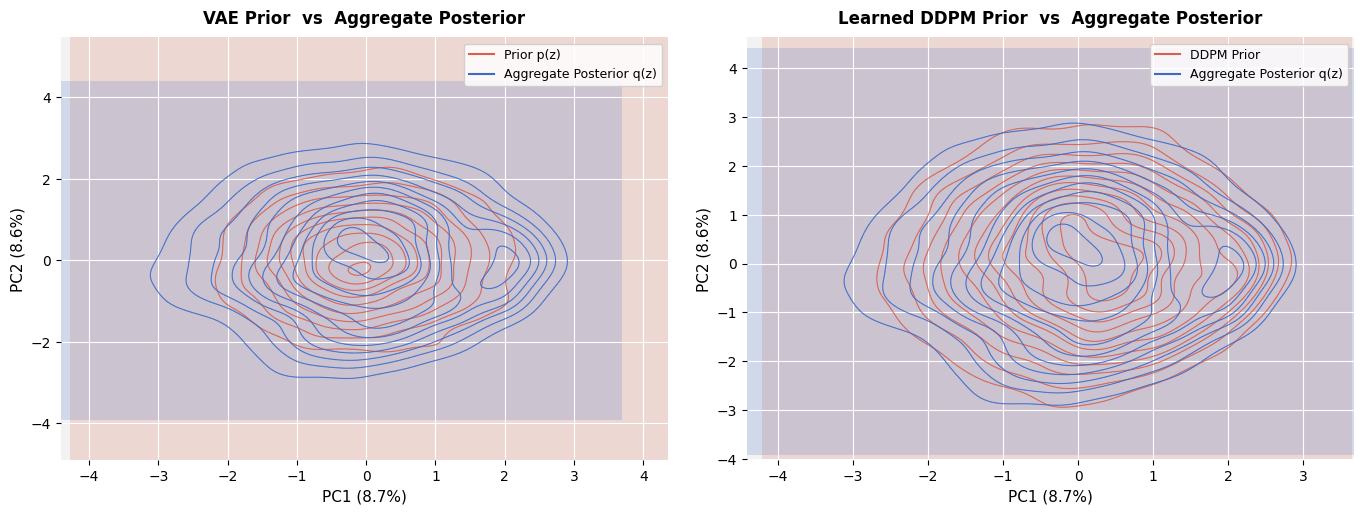

In [22]:
plot_latent_distributions(
    latent_ddpm,
    train_loader,
    dims=(0, 1),
    n_samples=5000,
    save_path=OUTDIR / 'latent_distributions.png',
)